# Proxy Logic
**Since we don’t have time-series, we simulate behavioral change using:**
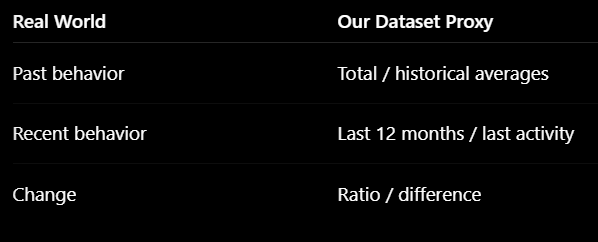

We are creating:
**Behavioral Drift = Expected Behavior - Current Behavior**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,VIP_Flag
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,Existing Customer,40,F,4,High School,Not_Disclosed,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [7]:
df["Churn"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df["Churn"].value_counts()

Churn
0    8500
1    1627
Name: count, dtype: int64

# FEATURE ENGINEERING — Behavioral Drift

**Transaction Drift**
- Compare Expected monthly transactions vs Recent transaction rate

In [8]:
df["Expected_Transactions"] = df["Total_Trans_Ct"] / df["Months_on_book"]
print(df["Expected_Transactions"].describe())

count    10127.000000
mean         1.923120
std          0.911977
min          0.188679
25%          1.272727
50%          1.857143
75%          2.361111
max          9.769231
Name: Expected_Transactions, dtype: float64


In [9]:
df["Recent_Transactions"] = df["Total_Trans_Ct"] / 12
print(df["Recent_Transactions"].describe())

count    10127.000000
mean         5.404891
std          1.956048
min          0.833333
25%          3.750000
50%          5.583333
75%          6.750000
max         11.583333
Name: Recent_Transactions, dtype: float64


In [10]:
df["Transaction_Drift"] = df["Recent_Transactions"] - df["Expected_Transactions"]
print(df["Transaction_Drift"].describe())

count    10127.000000
mean         3.481771
std          1.383664
min          0.128205
25%          2.333333
50%          3.555556
75%          4.444444
max          8.683673
Name: Transaction_Drift, dtype: float64


**Interpretation**
- Negative value --> Declining activity
- Positive Value --> Increasing activity

**Spend Drift**

In [12]:
df["Expected_Spend"] = df["Total_Trans_Amt"] / df["Months_on_book"]
print(df["Expected_Spend"].head())

0    29.333333
1    29.340909
2    52.416667
3    34.441176
4    38.857143
Name: Expected_Spend, dtype: float64


In [13]:
df["Recent_Spend"] = df["Total_Trans_Amt"] / 12
print(df["Recent_Spend"].head())

0     95.333333
1    107.583333
2    157.250000
3     97.583333
4     68.000000
Name: Recent_Spend, dtype: float64


In [15]:
df["Spend_Drift"] = df["Recent_Spend"] - df["Expected_Spend"]
print(df["Spend_Drift"].head())

0     66.000000
1     78.242424
2    104.833333
3     63.142157
4     29.142857
Name: Spend_Drift, dtype: float64


**Engagement Drift**

In [16]:
df["Engagement"] = df["Total_Trans_Ct"] / df["Months_on_book"]
print(df["Engagement"].head())

0    1.076923
1    0.750000
2    0.555556
3    0.588235
4    1.333333
Name: Engagement, dtype: float64


In [17]:
df["Engagement_Recent"] = df["Total_Trans_Ct"] / 12
print(df["Engagement_Recent"].head())

0    3.500000
1    2.750000
2    1.666667
3    1.666667
4    2.333333
Name: Engagement_Recent, dtype: float64


In [18]:
df["Engagement_Drift"] = df["Engagement_Recent"] - df["Engagement"]
print(df["Engagement_Drift"].head())

0    2.423077
1    2.000000
2    1.111111
3    1.078431
4    1.000000
Name: Engagement_Drift, dtype: float64


**Inactivity Risk Feature**

In [19]:
df["Inactivity_Risk"] = (
    df["Months_Inactive_12_mon"] / 12
)
print(df["Inactivity_Risk"].head())

0    0.083333
1    0.083333
2    0.083333
3    0.333333
4    0.083333
Name: Inactivity_Risk, dtype: float64


**Composite Behavioral Risk Score**

In [20]:
df["Behavioral_Risk_Score"] = (
    -df["Transaction_Drift"] * 0.4 +
    -df["Spend_Drift"] * 0.3 +
    df["Inactivity_Risk"] * 0.3
)
print(df["Behavioral_Risk_Score"].head())

0   -20.744231
1   -24.247727
2   -31.869444
3   -19.274020
4    -9.117857
Name: Behavioral_Risk_Score, dtype: float64


**Why negative?**
- Because **Negative drift** = BAD → we convert into positive risk

# VISUALIZATION

**Transaction Drift Distribution**

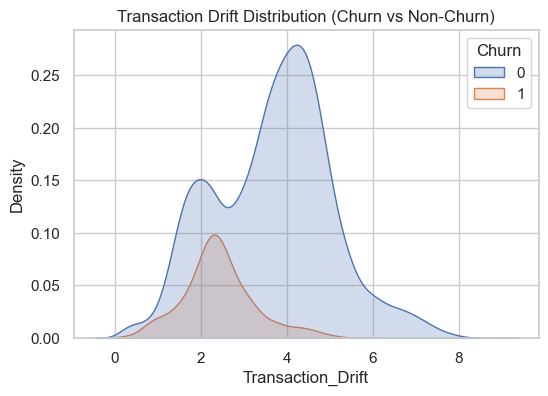

In [22]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="Transaction_Drift", hue="Churn", fill=True)
plt.title("Transaction Drift Distribution (Churn vs Non-Churn)")
plt.show()

**Insight (Expected)**
- Churn users → left shift (negative drift)
- Non-churn → stable or positive

**Spend Drift**

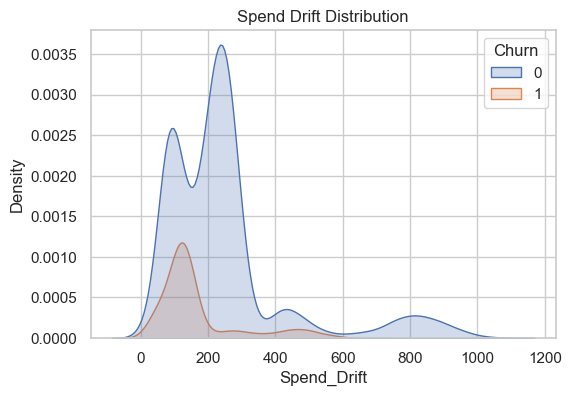

In [23]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="Spend_Drift", hue="Churn", fill=True)
plt.title("Spend Drift Distribution")
plt.show()

**Behavioral Risk Score**

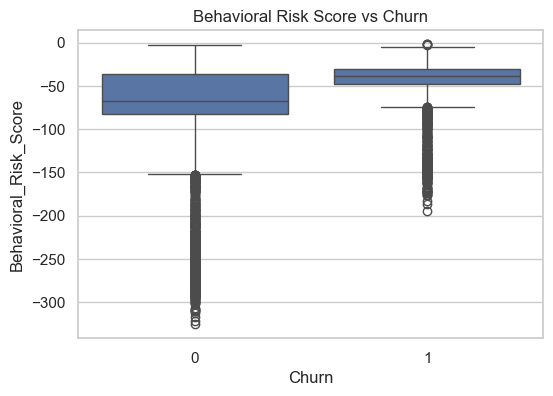

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="Behavioral_Risk_Score")
plt.title("Behavioral Risk Score vs Churn")
plt.show()

Higher score → higher churn probability

# Drift Bucketing 

**Drift Categories**

In [25]:
df["Drift_Category"] = pd.qcut(
    df["Transaction_Drift"],
    q=4,
    labels=["High Decline", "Moderate Decline", "Stable", "Growth"],
    duplicates="drop"
)
print(df["Drift_Category"].value_counts())

Drift_Category
Stable              2548
High Decline        2541
Moderate Decline    2535
Growth              2503
Name: count, dtype: int64


**Churn Rate by Drift**

C:\Users\91914\AppData\Local\Temp\ipykernel_15520\647240421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drift_churn = df.groupby("Drift_Category")["Churn"].mean()


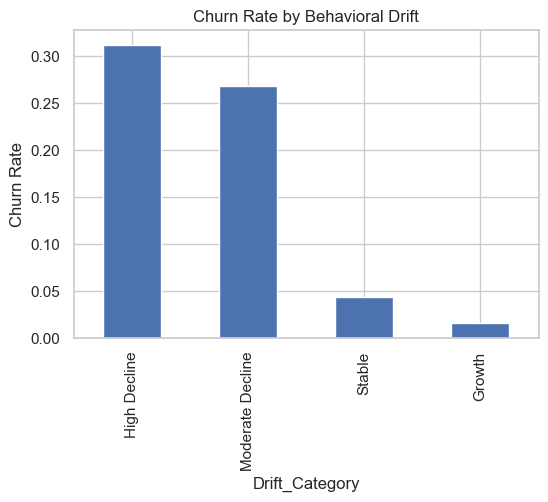

In [26]:
drift_churn = df.groupby("Drift_Category")["Churn"].mean()

drift_churn.plot(kind="bar", figsize=(6,4))
plt.title("Churn Rate by Behavioral Drift")
plt.ylabel("Churn Rate")
plt.show()

**Insight:**
- High Decline → Highest churn

- THIS = Early Warning Signal 

# MULTI-DIMENSIONAL DRIFT

**Combine:**
- Drift
- Inactivity

C:\Users\91914\AppData\Local\Temp\ipykernel_15520\3320706841.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


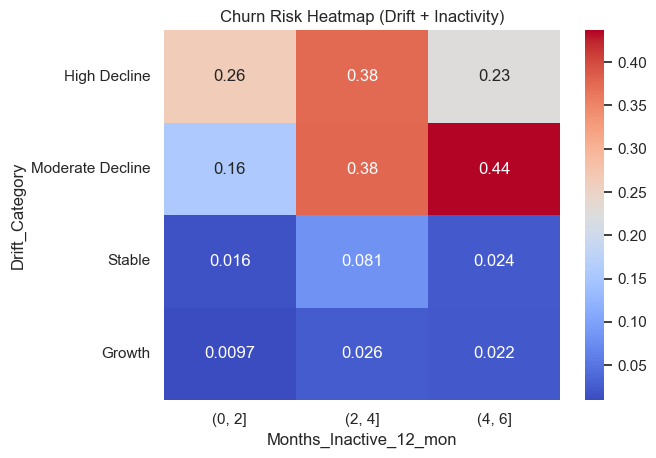

In [27]:
pivot = pd.pivot_table(
    df,
    values="Churn",
    index="Drift_Category",
    columns=pd.cut(df["Months_Inactive_12_mon"], bins=[0,2,4,6]),
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Churn Risk Heatmap (Drift + Inactivity)")
plt.show()

Decline + High inactivity = MAX churn risk

# STATISTICAL VALIDATION

In [28]:
from scipy.stats import ttest_ind

churned = df[df["Churn"] == 1]["Transaction_Drift"]
non_churned = df[df["Churn"] == 0]["Transaction_Drift"]

ttest_ind(churned, non_churned)

TtestResult(statistic=np.float64(-35.86292762886377), pvalue=np.float64(2.8522299344230866e-265), df=np.float64(10125.0))

In [29]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt(
        (x.std()**2 + y.std()**2) / 2
    )

cohens_d(churned, non_churned)

np.float64(-1.1071519421536657)

In [30]:
print("Churned Mean Drift:", churned.mean())
print("Non-Churned Mean Drift:", non_churned.mean())

Churned Mean Drift: 2.420060853768804
Non-Churned Mean Drift: 3.684994981295775


In [31]:
def mean_ci(data, confidence=0.95):
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    margin = 1.96 * se
    return mean - margin, mean + margin

print("Churned CI:", mean_ci(churned))
print("Non-Churned CI:", mean_ci(non_churned))

Churned CI: (np.float64(2.3786712238309047), np.float64(2.4614504837067033))
Non-Churned CI: (np.float64(3.6558061043463446), np.float64(3.7141838582452054))


Users who churn exhibit a significant decline in transactional behavior 
prior to churn, with a large effect size (Cohen’s d ≈ -1.1).

This confirms that behavioral drift is not only statistically significant 
but also practically meaningful, making it a powerful early warning signal.

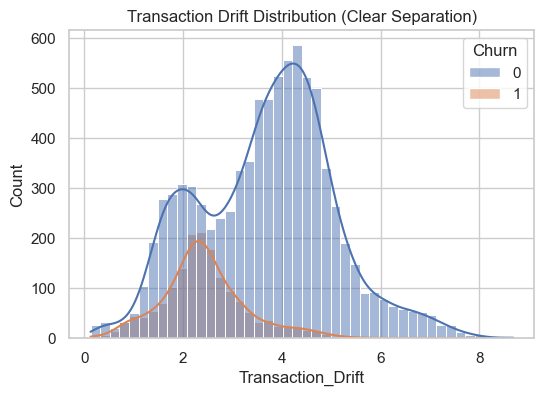

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Transaction_Drift", hue="Churn", kde=True)
plt.title("Transaction Drift Distribution (Clear Separation)")
plt.show()

Customers do not churn suddenly.

They gradually reduce engagement, reflected as a sharp decline in transaction activity.

This behavioral decay is measurable and statistically validated.

1. Churn users show strong negative behavioral drift
2. Decline in transactions precedes churn
3. Spend reduction is a secondary but strong signal
4. Inactivity amplifies churn risk
5. Behavioral Risk Score successfully separates churn vs non-churn